(Probably) poorly-formatted code written for presentation at British Antarctic Survey, Cambridge, UK, 2025-07-10.

Code will need to emulate Mitchell et al. 2011 data at 3 different timescales of forcing: 0.1, 1, and 10 year timescales.

Plots that need to be made:
- forcing and concentration plots at 3 different timescales
- walk-through plots concentration plots at 3 different timescales + firn smoothing + mitchell et al sampling
- walk-through plots of the mitchell data + firn smoothed + sampled data with all timescales
- power spectra of ensembles of firn-smoothed data at 3 different timescales + mitchell et al power spectrum

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.timeseries import LombScargle
from pathlib import Path

from methane_noise_forcing import simulate_two_timescale_ar1
from methane_noise_forcing.core import FirnFilter, sample_series_at_core_points

In [2]:
# paths and global constants
path_methane = (
    "/Users/ericm/Documents/Research/methane_noise_forcing/data/mitchell_ch4.csv"
)
path_figures = Path(
    "/Users/ericm/Documents/Research/methane_noise_forcing/figures/BAS_presentation"
)
Tg_per_ppb = 2.75  # Tg/ppb, approximate global conversion for methane

# import mitchell 2011 data

In [3]:
path_methane = "/Users/ericm/Documents/Research/intro_and_motivation_figs/data/ch4/past_2000/WDC05A_mitchell2011.csv"

age_col = 'Gas Age (Year C.E., timescale:"WDC05A:2")'
df = pd.read_csv(
    path_methane, usecols=["Mean depth (m)", age_col, "Mean Concentration (ppb)"]
).rename(columns={age_col: "Gas_Age_CE"})

df["Gas_Age_CE"] = df["Gas_Age_CE"].astype(float)

# filter data: max gas age is 1750 CE
df_filtered = df[df["Gas_Age_CE"] <= 1750].copy()
mitchell_time = df_filtered["Gas_Age_CE"].values
mitchell_ch4 = df_filtered["Mean Concentration (ppb)"].values

Total linear trend over 727.2 years: 16.98 ppb


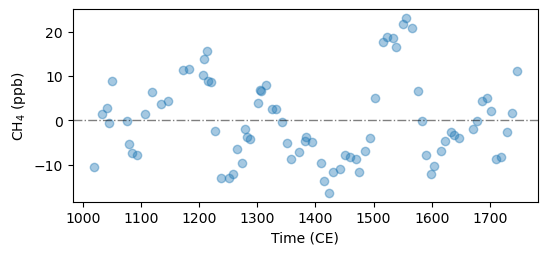

In [4]:
# what is the total component of the linear trend?
coeffs = np.polyfit(mitchell_time, mitchell_ch4, 1)
time_interval = mitchell_time[0] - mitchell_time[-1]
total_linear_trend = coeffs[0] * time_interval
print(
    f"Total linear trend over {time_interval:0.1f} years: {total_linear_trend:.2f} ppb"
)

## deseasonalized mitchell data
mitchell_detrended = mitchell_ch4 - (coeffs[0] * mitchell_time + coeffs[1])

# plot de-trended mitchell data
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5), sharex=True)

ax.plot(
    mitchell_time,
    mitchell_detrended,
    "o",
    label="Mitchell Detrended Data",
    color="tab:blue",
    alpha=0.4,
)
ax.axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_xlabel("Time (CE)")

# save figure
fig_name = path_figures / "mitchell_detrended.pdf"
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

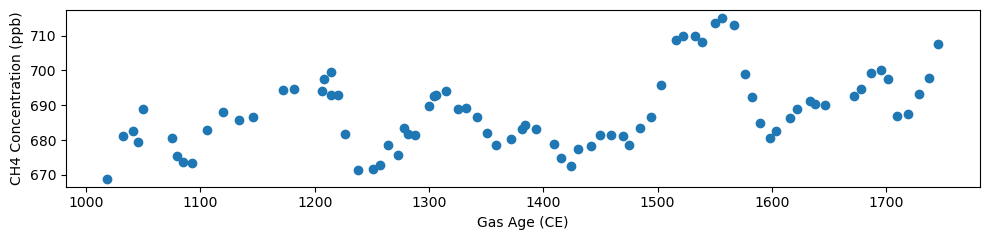

In [5]:
# plot data
fig, ax = plt.subplots(1, 1, figsize=(10, 2.5), sharex=True)
ax.plot(mitchell_time, mitchell_ch4, "o", label="Original Data")
ax.set_ylabel("CH4 Concentration (ppb)")
ax.set_xlabel("Gas Age (CE)")
plt.tight_layout()

# run noise and sampling code

In [6]:
## global characteristics of the noise
tau_ch4 = 10.0
dt = 1 / 24  # time step [years]
years = 1200  # length of each simulation [years], 400 years spinup
n_ens = 10  # number of ensemble members
N = int(years / dt)

In [7]:
## variable characteristics of the noise depending on the noise timescale
noise_timescales = [0.1, 1, 2, 10, 100]  # years
noise_variances = {  # 225 ppb^2 is the starting point
    0.1: 275,  # ppb^2
    1: 240,  # ppb^2
    2: 220,  # ppb^2
    10: 170,  # ppb^2
    100: 160,  # ppb^2
}

In [8]:
## firn filter parameters
mode = 25  # years
fwhm = 22  # years

firn_filter = FirnFilter.from_gamma(mode=mode, fwhm=fwhm, dt=0.5)

## ice core sampler parameters
core_offset = 1018.62  # offset in years
series_offset = 400  # offset in years

In [ ]:
# holds all realizations of noise forcing for one timescale
class NoiseResultsOneTimescale:
    def __init__(
        self, ch4_ens, forcing_ens, time, ch4_smoothed_ens, ch4_pseudoproxy_ens
    ):
        self.ch4_ens = ch4_ens
        self.forcing_ens = forcing_ens
        self.time = time
        self.ch4_smoothed_ens = ch4_smoothed_ens
        self.ch4_pseudoproxy_ens = ch4_pseudoproxy_ens


noise_results = {}

for forcing_timescale in noise_timescales:
    # simulate noise forcing
    ch4_ens, forcing_ens = simulate_two_timescale_ar1(
        tau_x=tau_ch4,
        tau_eta=forcing_timescale,
        variance_x=noise_variances[forcing_timescale],
        dt=dt,
        N=N,
        n_ens=n_ens,
    )

    # calculate firn smoothing and pseudoproxy sampling
    ch4_smoothed_ens = np.zeros((n_ens, N))
    ch4_pseudoproxy_ens = np.zeros((n_ens, len(mitchell_time)))
    for idx_ens in range(n_ens):
        ch4_smoothed = firn_filter.apply(ch4_ens[idx_ens, :], dt_series=dt)
        ch4_pseudoproxy = sample_series_at_core_points(
            series_time=np.arange(N) * dt,
            core_time=mitchell_time,
            series_to_sample=ch4_smoothed,
            core_offset=core_offset,  # offset in years
            series_offset=series_offset,  # offset in years
        )
        # store results
        ch4_smoothed_ens[idx_ens, :] = ch4_smoothed
        ch4_pseudoproxy_ens[idx_ens, :] = ch4_pseudoproxy

    # store results in a class
    noise_results[forcing_timescale] = NoiseResultsOneTimescale(
        ch4_ens=ch4_ens,
        forcing_ens=forcing_ens,
        time=np.arange(N) * dt,
        ch4_smoothed_ens=ch4_smoothed_ens,
        ch4_pseudoproxy_ens=ch4_pseudoproxy_ens,
    )

In [10]:
## compare std of sampled timeseries to std of mitchell data
mitchell_std = np.std(mitchell_ch4, ddof=1)
print(f"Mitchell std: {mitchell_std:.2f} ppb")
for forcing_timescale, results in noise_results.items():
    # calculate mean and std of of standard deviation of ensemble members
    ch4_std_ens = np.std(results.ch4_pseudoproxy_ens, axis=1, ddof=1)
    ch4_std_mean = np.mean(ch4_std_ens)
    ch4_std_std = np.std(ch4_std_ens, ddof=1)
    print(
        f"Std of sampled timeseries for forcing timescale {forcing_timescale} years: {ch4_std_mean:.2f} ± {ch4_std_std:.2f} ppb"
    )

Mitchell std: 10.64 ppb
Std of sampled timeseries for forcing timescale 0.1 years: 10.69 ± 1.60 ppb
Std of sampled timeseries for forcing timescale 1 years: 9.98 ± 1.57 ppb
Std of sampled timeseries for forcing timescale 2 years: 9.64 ± 1.35 ppb
Std of sampled timeseries for forcing timescale 10 years: 10.81 ± 2.06 ppb
Std of sampled timeseries for forcing timescale 100 years: 9.22 ± 2.48 ppb


# Plots

## plot forcing data for different timescales

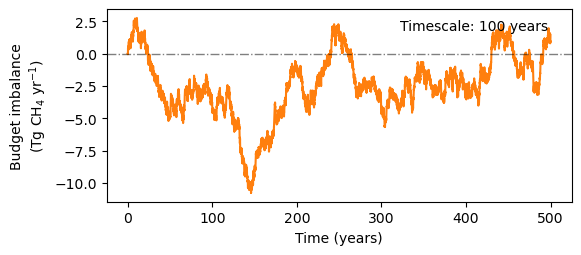

In [11]:
# parameters
forcing_timescale = 100
idx_ens = 2
n_years_plot = 500  # plot first n years of the simulation

fig, ax = plt.subplots(1, 1, figsize=(6, 2.5), sharex=True)
idx_mask = noise_results[forcing_timescale].time < n_years_plot
forcing_plot = (
    noise_results[forcing_timescale].forcing_ens[idx_ens, idx_mask] * Tg_per_ppb
)

ax.plot(
    noise_results[forcing_timescale].time[idx_mask], forcing_plot, color="tab:orange"
)
ax.axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
ax.set_ylabel("Budget imbalance\n(Tg CH$_4$ yr$^{-1}$)")
ax.set_xlabel("Time (years)")
# print timescale of forcing
ax.text(
    0.95,
    0.95,
    f"Timescale: {forcing_timescale} years",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
)

fig_name = path_figures / f"forcing_timescale-{forcing_timescale}.pdf"
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

## walk-through of concentration plot with forcing and mitchell et al sampling

In [12]:
# parameters
forcing_timescale = 2
idx_ens = 0
n_years_plot_min = 200
n_years_plot_max = 1200
pseudosample_time = mitchell_time + series_offset - core_offset

# calculated quantities for plotting
idx_mask = (noise_results[forcing_timescale].time < n_years_plot_max) & (
    noise_results[forcing_timescale].time > n_years_plot_min
)
time_plot = noise_results[forcing_timescale].time[idx_mask]
forcing_plot = (
    noise_results[forcing_timescale].forcing_ens[idx_ens, idx_mask] * Tg_per_ppb
)
ch4_pseudoproxy_plot = noise_results[forcing_timescale].ch4_pseudoproxy_ens[idx_ens, :]
ch4_smoothed_plot = noise_results[forcing_timescale].ch4_smoothed_ens[idx_ens, idx_mask]
ch4_plot = noise_results[forcing_timescale].ch4_ens[idx_ens, idx_mask]

/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_59051/3085253758.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


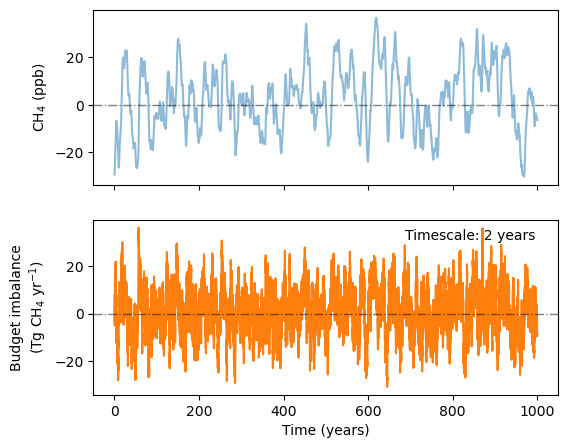

In [13]:
## figure with raw
fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# top panel: all ch4
axs[0].plot(
    time_plot,
    ch4_plot,
    color="tab:blue",
    alpha=0.5,
    label="Simulated CH$_4$",
)
axs[0].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[0].set_ylabel("CH$_4$ (ppb)")

# bottom panel: forcing
axs[1].plot(
    time_plot,
    forcing_plot,
    color="tab:orange",
)
axs[1].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[1].set_ylabel("Budget imbalance\n(Tg CH$_4$ yr$^{-1}$)")
axs[1].set_xlabel("Time (years)")
# print timescale of forcing
axs[1].text(
    0.95,
    0.95,
    f"Timescale: {forcing_timescale} years",
    transform=axs[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
)

# change the x axis ticks to start at 0
axs[1].set_xticklabels([f"{int(t):d}" for t in axs[1].get_xticks() - n_years_plot_min])

# save figure
fig_name = path_figures / f"noise_forcing_timescale-{forcing_timescale}_buildup-0.pdf"
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_59051/3078175951.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


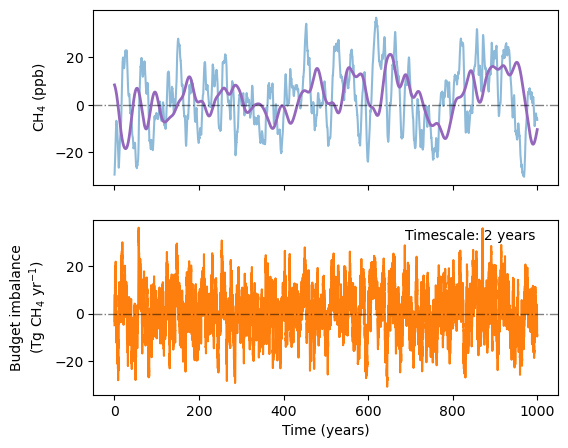

In [14]:
## figure with raw + smoothed
fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# top panel: all ch4
axs[0].plot(
    time_plot,
    ch4_plot,
    color="tab:blue",
    alpha=0.5,
    label="Simulated CH$_4$",
)
axs[0].plot(
    time_plot,
    ch4_smoothed_plot,
    color="tab:purple",
    label="Smoothed CH$_4$",
    linewidth=2,
)
axs[0].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[0].set_ylabel("CH$_4$ (ppb)")

# bottom panel: forcing
axs[1].plot(
    time_plot,
    forcing_plot,
    color="tab:orange",
)
axs[1].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[1].set_ylabel("Budget imbalance\n(Tg CH$_4$ yr$^{-1}$)")
axs[1].set_xlabel("Time (years)")
# print timescale of forcing
axs[1].text(
    0.95,
    0.95,
    f"Timescale: {forcing_timescale} years",
    transform=axs[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
)

# change the x axis ticks to start at 0
axs[1].set_xticklabels([f"{int(t):d}" for t in axs[1].get_xticks() - n_years_plot_min])

# save figure
fig_name = path_figures / f"noise_forcing_timescale-{forcing_timescale}_buildup-1.pdf"
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_59051/920155470.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


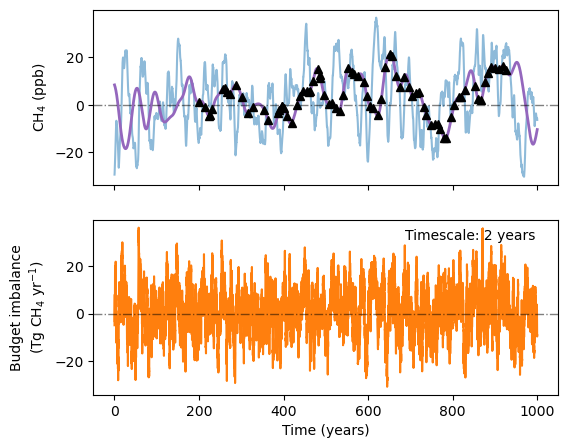

In [15]:
## figure with raw + smoothed + sampled
fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# top panel: all ch4
axs[0].plot(
    time_plot,
    ch4_plot,
    color="tab:blue",
    alpha=0.5,
    label="Simulated CH$_4$",
)
axs[0].plot(
    time_plot,
    ch4_smoothed_plot,
    color="tab:purple",
    label="Smoothed CH$_4$",
    linewidth=2,
)
axs[0].plot(
    pseudosample_time,
    ch4_pseudoproxy_plot,
    "^",
    color="k",
    markersize=6,
    label="Pseudoproxy CH$_4$",
)
axs[0].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[0].set_ylabel("CH$_4$ (ppb)")

# bottom panel: forcing
axs[1].plot(
    time_plot,
    forcing_plot,
    color="tab:orange",
)
axs[1].axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
axs[1].set_ylabel("Budget imbalance\n(Tg CH$_4$ yr$^{-1}$)")
axs[1].set_xlabel("Time (years)")
# print timescale of forcing
axs[1].text(
    0.95,
    0.95,
    f"Timescale: {forcing_timescale} years",
    transform=axs[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
)

# change the x axis ticks to start at 0
axs[1].set_xticklabels([f"{int(t):d}" for t in axs[1].get_xticks() - n_years_plot_min])

# save figure
fig_name = path_figures / f"noise_forcing_timescale-{forcing_timescale}_buildup-2.pdf"
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

## plot de-trended mitchell data with sampled forcing

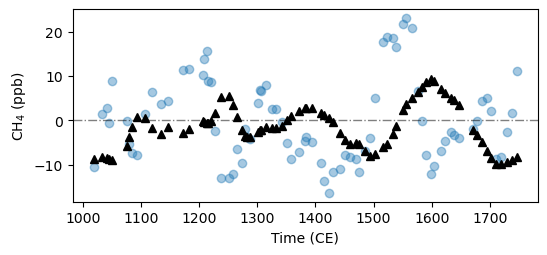

In [16]:
## parameters of noise data
forcing_timescale = 100
idx_ens = 2
# calculated quantities for plotting
ch4_pseudoproxy_plot = noise_results[forcing_timescale].ch4_pseudoproxy_ens[idx_ens, :]

# plot in timeseries
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5), sharex=True)

ax.plot(
    mitchell_time,
    mitchell_detrended,
    "o",
    label="Mitchell Detrended Data",
    color="tab:blue",
    alpha=0.4,
)
ax.plot(
    mitchell_time,
    ch4_pseudoproxy_plot,
    "^",
    color="k",
    markersize=6,
    label="Pseudoproxy CH$_4$",
)
ax.axhline(0, color="k", linestyle="-.", linewidth=1, alpha=0.5)
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_xlabel("Time (CE)")

# save figure
fig_name = (
    path_figures / f"mitchell_detrended_pseudoproxy_timescale-{forcing_timescale}.pdf"
)
plt.savefig(fig_name, bbox_inches="tight", dpi=300)

# Generate power spectra of ensembles

In [ ]:
## power spectra of mitchell data
frequency_min = 2 / (mitchell_time.max() - mitchell_time.min())
frequency_max = 0.5 / np.median(np.abs(np.diff(mitchell_time)))

frequency_mitchell, power_mitchell = LombScargle(
    mitchell_time, mitchell_ch4, nterms=1
).autopower(
    minimum_frequency=frequency_min,
    maximum_frequency=frequency_max,
    samples_per_peak=5,
    normalization="psd",
)

In [19]:
## calculate power spectra of noise forcing
ch4_pseudoproxy_psds = {}

for forcing_timescale, results in noise_results.items():
    # calculate power spectra for each ensemble member
    psds = np.zeros((n_ens, len(frequency_mitchell)))
    for idx_ens in range(n_ens):
        frequency, power = LombScargle(
            mitchell_time,
            results.ch4_pseudoproxy_ens[idx_ens, :],
            nterms=1,
        ).autopower(
            minimum_frequency=frequency_min,
            maximum_frequency=frequency_max,
            samples_per_peak=5,
            normalization="psd",
        )
        psds[idx_ens, :] = power

    # store results
    ch4_pseudoproxy_psds[forcing_timescale] = psds

Text(0, 0.5, 'Power (ppb$^2$ year)')

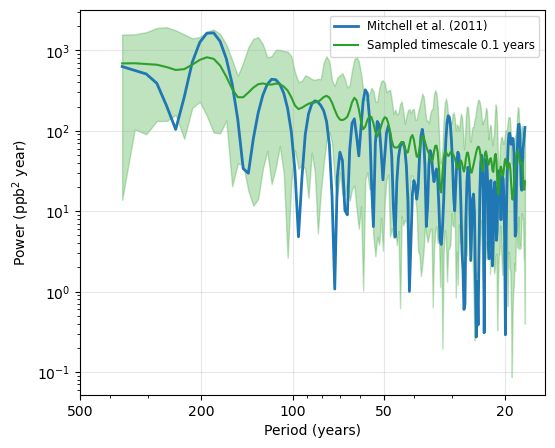

In [32]:
# plot PSD and ensemble
forcing_timescale = 0.1

# calculate 2.5 and 97.5 percentiles of the ensemble
psd_ens_2_5 = np.percentile(ch4_pseudoproxy_psds[forcing_timescale], 2.5, axis=0)
psd_ens_97_5 = np.percentile(ch4_pseudoproxy_psds[forcing_timescale], 97.5, axis=0)
psd_ens_mean = np.mean(ch4_pseudoproxy_psds[forcing_timescale], axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
# mitchell data
ax.loglog(
    1 / frequency_mitchell,
    power_mitchell,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)

# sampled data
ax.loglog(
    1 / frequency_mitchell,
    psd_ens_mean,
    label=f"Sampled timescale {forcing_timescale} years",
    color="tab:green",
)
# 2.5 and 97.5 percentiles
ax.fill_between(
    1 / frequency_mitchell,
    psd_ens_2_5,
    psd_ens_97_5,
    color="tab:green",
    alpha=0.3,
)

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20]]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
# ax.set_ylim([1, 5e3])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$ year)")